# Análise exploratória da ação (PETR4)

O notebook lê `equity_daily` no snapshot `data/gas_flare.sqlite`. O ticker padrão é **PETR4**. O recorte usa a âncora do PPI (`MIN(ppi_daily.report_date)`).

O início nativo neste snapshot é **2022-02-01**. Janeiro de 2022 fica sem barras de PETR4 no índice do PPI.

Colunas usadas: `price_open` / `price_max` / `price_min` / `price_med` / `price_last`, `total_quantity`, `vol_hist` / `vol_hist_021` / `vol_hist_126` / `vol_hist_252`.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url, table_exists

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL


'sqlite:////mnt/opencode/proj_IV/data/gas_flare.sqlite'

In [2]:
TABLE = 'equity_daily'
TICKER = 'PETR4'

def read_table(engine, sql):
    try:
        return pd.read_sql_query(sql, engine)
    except Exception as exc:
        print(f'Skipping query ({exc})')
        return pd.DataFrame()

if not table_exists(ENGINE, TABLE):
    print(f'Missing table: {TABLE} in data/gas_flare.sqlite')
    eq = pd.DataFrame()
else:
    eq = read_table(
        ENGINE,
        f"""
        SELECT tradedate, ticker,
               price_open, price_max, price_min, price_med, price_last,
               total_quantity, total_transactions, total_cash,
               vol_hist, vol_hist_021, vol_hist_126, vol_hist_252,
               source_db, ingested_at
        FROM {TABLE}
        WHERE ticker = '{TICKER}'
        ORDER BY tradedate
        """,
    )

ppi_anchor = pd.to_datetime(
    pd.read_sql_query('SELECT MIN(report_date) AS d FROM ppi_daily', ENGINE).iloc[0, 0]
)
print(f'PPI anchor: {ppi_anchor.date()}')

price_cols = ['price_open', 'price_max', 'price_min', 'price_med', 'price_last']
vol_cols = ['vol_hist', 'vol_hist_021', 'vol_hist_126', 'vol_hist_252']

if eq.empty:
    print(f'{TABLE} has no {TICKER} rows.')
else:
    eq['tradedate'] = pd.to_datetime(eq['tradedate'], errors='coerce')
    for col in price_cols + vol_cols + ['total_quantity', 'total_transactions', 'total_cash']:
        if col in eq.columns:
            eq[col] = pd.to_numeric(eq[col], errors='coerce')
    eq = eq[eq['tradedate'] >= ppi_anchor].copy()
    print(f'Rows: {len(eq):,}  ticker={TICKER}')
    print(f"Date range: {eq['tradedate'].min().date()} to {eq['tradedate'].max().date()}")

eq.head()


PPI anchor: 2022-01-05
Rows: 1,134  ticker=PETR4
Date range: 2022-02-01 to 2026-08-18


,tradedate,ticker,price_open,price_max,price_min,price_med,price_last,total_quantity,total_transactions,total_cash,vol_hist,vol_hist_021,vol_hist_126,vol_hist_252,source_db,ingested_at
0,2022-02-01,PETR4,32.35,33.32,31.95,32.83,33.00,57315200,92039,1.882094e+09,0.453430,0.312568,0.372132,0.453430,dadodb_dev,2026-08-18 19:56:02.389215
1,2022-02-02,PETR4,33.41,33.49,32.36,32.64,32.52,36271700,80693,1.184107e+09,0.453500,0.315406,0.371728,0.453500,dadodb_dev,2026-08-18 19:56:02.389215
2,2022-02-03,PETR4,32.35,32.92,31.62,32.03,32.07,51087800,92360,1.636398e+09,0.451970,0.321611,0.371766,0.451970,dadodb_dev,2026-08-18 19:56:02.389215
3,2022-02-04,PETR4,32.41,33.23,31.88,32.78,32.63,59346800,94572,1.945650e+09,0.451260,0.286011,0.371007,0.451260,dadodb_dev,2026-08-18 19:56:02.389215
4,2022-02-07,PETR4,32.55,32.78,32.13,32.36,32.15,48868100,76874,1.581855e+09,0.449777,0.293973,0.356484,0.449777,dadodb_dev,2026-08-18 19:56:02.389215


In [3]:
if eq.empty:
    print('No equity rows to summarise.')
else:
    petr = eq.set_index('tradedate').sort_index()
    bdays = pd.bdate_range(petr.index.min(), petr.index.max())
    missing = bdays.difference(petr.index)
    print(f'Business days in span: {len(bdays)}')
    print(f'Trading bars: {len(petr)}')
    print(f'Business days with no bar: {len(missing)} (holidays / unscheduled gaps)')
    coverage = pd.DataFrame({
        'column': price_cols + ['total_quantity'] + vol_cols,
        'nulls': [int(petr[c].isna().sum()) if c in petr.columns else None for c in price_cols + ['total_quantity'] + vol_cols],
        'last': [petr[c].dropna().iloc[-1] if c in petr.columns and petr[c].notna().any() else None for c in price_cols + ['total_quantity'] + vol_cols],
    })
    display(coverage)
    display(petr[price_cols + ['total_quantity']].tail(10))


Business days in span: 1186
Trading bars: 1134
Business days with no bar: 52 (holidays / unscheduled gaps)


,column,nulls,last
0,price_open,0,4.280000e+01
1,price_max,0,4.320000e+01
2,price_min,0,4.242000e+01
3,price_med,0,4.277000e+01
4,price_last,0,4.260000e+01
5,total_quantity,0,3.683810e+07
6,vol_hist,0,2.522917e-01
7,vol_hist_021,0,2.597986e-01
8,vol_hist_126,0,2.914600e-01
9,vol_hist_252,0,2.522917e-01


,price_open,price_max,price_min,price_med,price_last,total_quantity
tradedate,,,,,,
2026-08-05,42.53,42.99,41.75,42.22,41.93,32365700
2026-08-06,42.02,42.47,41.92,42.18,42.13,46662600
2026-08-07,42.90,42.96,40.83,41.46,40.87,97926700
2026-08-10,41.32,42.47,41.06,41.88,42.23,74915200
2026-08-11,42.40,42.50,41.01,41.50,41.66,53988900
2026-08-12,41.50,41.97,41.15,41.58,41.45,63890300
2026-08-13,41.15,41.96,41.07,41.72,41.90,37063800
2026-08-14,41.63,42.46,41.63,42.08,42.09,34127900
2026-08-17,42.35,42.76,41.72,42.42,42.47,47636500


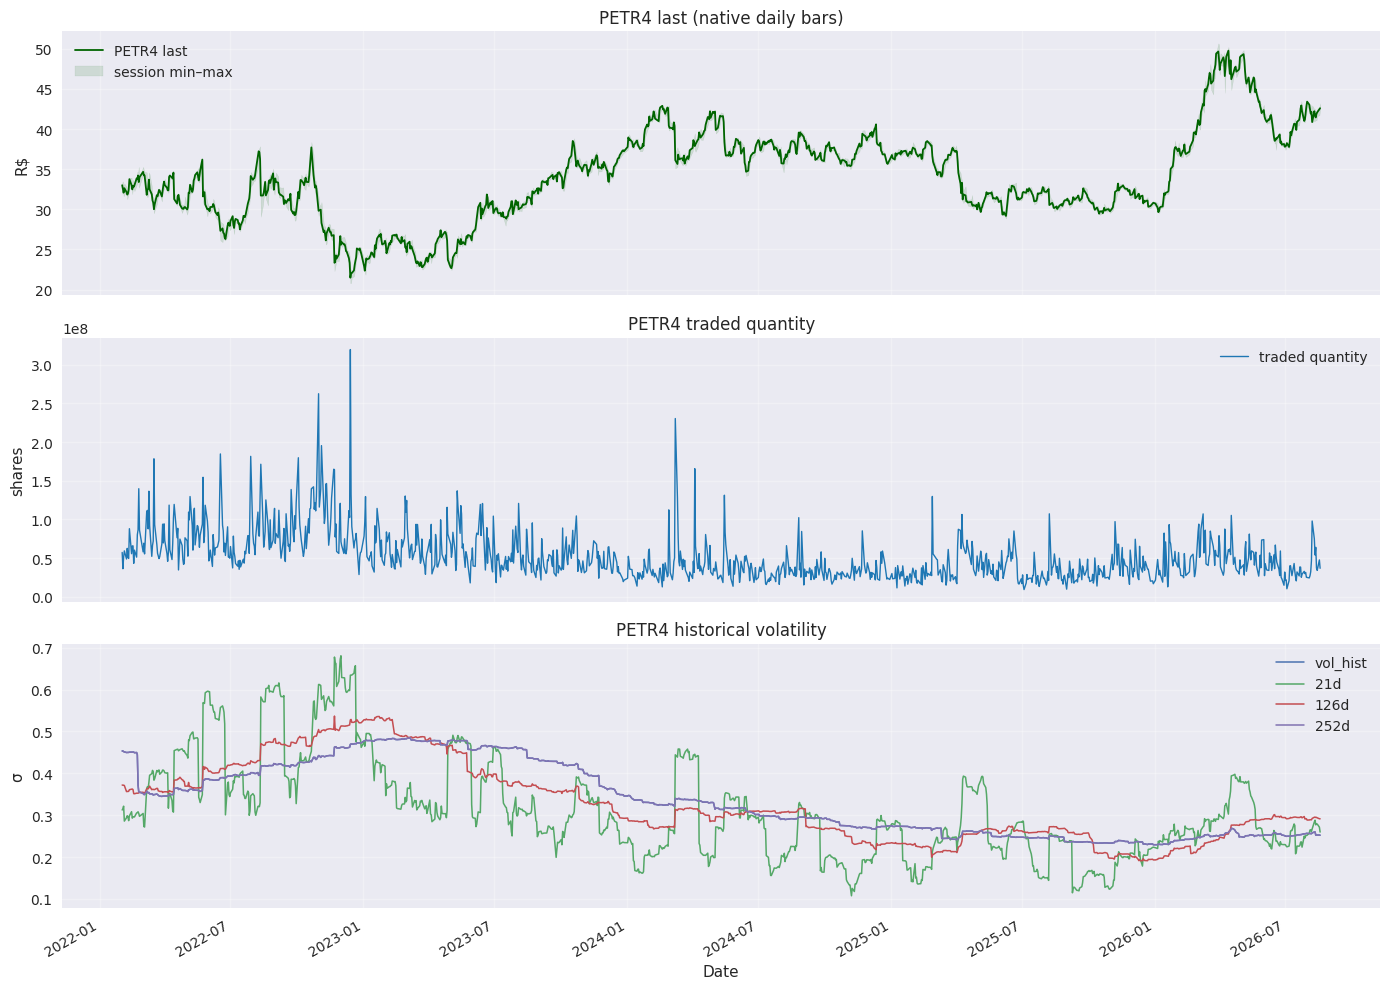

In [4]:
if eq.empty:
    print('No equity rows to plot.')
else:
    petr = eq.set_index('tradedate').sort_index()
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    ax.plot(petr.index, petr['price_last'], linewidth=1.3, color='darkgreen', label='PETR4 last')
    if petr['price_max'].notna().any() and petr['price_min'].notna().any():
        ax.fill_between(petr.index, petr['price_min'], petr['price_max'], color='darkgreen', alpha=0.12, label='session min–max')
    ax.set_ylabel('R$')
    ax.set_title('PETR4 last (native daily bars)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1]
    ax.plot(petr.index, petr['total_quantity'], linewidth=1.0, color='#1f77b4', label='traded quantity')
    ax.set_ylabel('shares')
    ax.set_title('PETR4 traded quantity')
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[2]
    for col, label in [
        ('vol_hist', 'vol_hist'),
        ('vol_hist_021', '21d'),
        ('vol_hist_126', '126d'),
        ('vol_hist_252', '252d'),
    ]:
        if col in petr.columns and petr[col].notna().any():
            ax.plot(petr.index, petr[col], linewidth=1.1, label=label)
    ax.set_ylabel('σ')
    ax.set_xlabel('Date')
    ax.set_title('PETR4 historical volatility')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()


In [5]:
if eq.empty:
    print('No equity rows to describe.')
else:
    petr = eq.set_index('tradedate').sort_index()
    display(petr[price_cols + ['total_quantity'] + [c for c in vol_cols if c in petr.columns]].describe().T.round(4))
    daily_ret = petr['price_last'].pct_change() * 100
    print(f'Daily last-to-last return %  mean={daily_ret.mean():.3f}  std={daily_ret.std():.3f}  n={daily_ret.dropna().shape[0]}')


,count,mean,std,min,25%,50%,75%,max
price_open,1134.0,3.404130e+01,5.500100e+00,2.100000e+01,3.055250e+01,3.365000e+01,3.765000e+01,5.007000e+01
price_max,1134.0,3.446370e+01,5.520600e+00,2.211000e+01,3.087500e+01,3.413500e+01,3.797750e+01,5.069000e+01
price_min,1134.0,3.362620e+01,5.486200e+00,2.077000e+01,3.016000e+01,3.313000e+01,3.730500e+01,4.949000e+01
price_med,1134.0,3.404110e+01,5.503000e+00,2.154000e+01,3.049500e+01,3.362500e+01,3.766000e+01,5.001000e+01
price_last,1134.0,3.405030e+01,5.506200e+00,2.147000e+01,3.056000e+01,3.359000e+01,3.767000e+01,4.978000e+01
total_quantity,1134.0,5.157617e+07,3.097903e+07,9.354700e+06,3.013652e+07,4.348830e+07,6.395990e+07,3.195016e+08
vol_hist,1134.0,3.364000e-01,8.580000e-02,2.296000e-01,2.529000e-01,3.172000e-01,4.196000e-01,4.853000e-01
vol_hist_021,1134.0,3.101000e-01,1.186000e-01,1.077000e-01,2.264000e-01,2.872000e-01,3.770000e-01,6.808000e-01
vol_hist_126,1134.0,3.280000e-01,9.360000e-02,1.914000e-01,2.588000e-01,3.031000e-01,3.848000e-01,5.368000e-01
vol_hist_252,1134.0,3.364000e-01,8.580000e-02,2.296000e-01,2.529000e-01,3.172000e-01,4.196000e-01,4.853000e-01


Daily last-to-last return %  mean=0.045  std=2.102  n=1133
